# Objectif du notebook 

Date de création : 02/03/2026

Application de la méthode RTF-MFP dans le cas intermédiaire library active / event passive à une situation favorable. 

<!-- Afin de démontrer la faisabilité de la méthode dans ce cas intermédiaire on cherche à appliquer la méthode RTF-MFP de manière analogue au notebook  rtf_mfp_library_active_trailed_event_passive.ipynb dans une situation plus favorable où un unique bateau se situe à proximité du réseau de capteurs.  -->

<!-- Pour ce faire, on cherche dans un premier temps à identifier une telle situation. On définit une zone circulaire $\mathcal{D}$ de rayon $R$ (on prendra $R=2~km$ comme première estimation)centrée sur le récepteur 2 au centre du réseau et une situation est jugée favorable si les critères suivants sont respectés : 

* La trajectoire d'un navire intersecte la zone $\mathcal{D}$. 
* Aucun n'autre navire n'est présent dans la zone $\mathcal{D}$ lors du transit du navire dans la zone $\mathcal{D}$.
* Le passage du navire au CPA est clairement identifiable sur au moins l'un des OBS.
* Aucune n'autre signature de navire n'est identifiable sur l'enregistrement correspondant à la période de transit du navire dans la zone $\mathcal{D}$.  -->



In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import timedelta, datetime, date
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_trailed_event_passive")
root_rtf_data_res = os.path.join(
    data_folder, "result_analysis", "library_active_trailed_event_passive"
)

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2_passive_event,
    # get_dists_2,
    # get_dists,
    derive_doppler_jules,
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    ActiveFiberscopeManager,
    PassiveFiberscopeManager,
    BandFilter,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_animation_utils import (
    rtf_mfp_animation,
)
from misc import progression_bar

# Chargement des données 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
# Load AIS
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
# Load bathy
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))
# Load wav
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))


# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
delta_lon = 0.1
delta_lat = 0.1
lon_min = ds_bathy.local_frame_origin_wgs84_lon - delta_lon
lon_max = ds_bathy.local_frame_origin_wgs84_lon + delta_lon
lat_min = ds_bathy.local_frame_origin_wgs84_lat - delta_lat
lat_max = ds_bathy.local_frame_origin_wgs84_lat + delta_lat

idx_x_min = np.argmin(np.abs(ds_bathy.lon.values - lon_min))
idx_x_max = np.argmin(np.abs(ds_bathy.lon.values - lon_max))
idx_y_min = np.argmin(np.abs(ds_bathy.lat.values - lat_min))
idx_y_max = np.argmin(np.abs(ds_bathy.lat.values - lat_max))

# Slice wgs84 coords
ds_bathy = ds_bathy.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
# Slice local coords
ds_bathy = ds_bathy.isel(e=slice(idx_y_min, idx_y_max), n=slice(idx_x_min, idx_x_max))

# Étape 1 : recherche d'une situation favorable 

In [6]:
# # Représentation sous forme de 24 vignettes de la situation AIS chaque heure
# day = date(2025, 10, 13)

# ais_day = ds_ais.sel(time=str(day))

# fig, axs = plt.subplots(4, 6, figsize=(20, 15), sharex=True, sharey=True)
# fig.suptitle(f"AIS tracks on {str(day)}")

# axs = axs.flatten()
# hours = np.arange(0, 24)
# for i, hour in enumerate(hours):
#     ax = axs[i]
#     ds_bathy.elevation.plot(ax=ax, add_colorbar=False)
#     ax.contour(
#         ds_bathy.lon,
#         ds_bathy.lat,
#         ds_bathy.elevation,
#         levels=[0],
#         colors="k",
#     )

#     ais_hour = ais_day.isel(time=ais_day.time.dt.hour == hour)
#     for ii, mmsi_i in enumerate(ais_hour.mmsi.values):
#         ais_hour_mmsi = ais_hour.sel(mmsi=mmsi_i)
#         ax.plot(
#             ais_hour_mmsi.lon,
#             ais_hour_mmsi.lat,
#             "-",
#             label=f"{mmsi_i}",
#             color=color(ii),
#         )

#     # Add GPS track of Jules
#     gps_day = ds_gps.sel(time=str(day))
#     gps_hour = gps_day.isel(time=gps_day.time.dt.hour == hour)
#     ax.plot(
#         gps_hour.lon,
#         gps_hour.lat,
#         "o-",
#         label="Jules GPS",
#         color="black",
#         markersize=4,
#     )
#     ax.set_title(f"{hour:02d}h")
#     ax.set_xlabel("")
#     ax.set_ylabel("")

# fig.supxlabel("Longitude [°]")
# fig.supylabel("Latitude [°]")

# Construction de la librairie de répliques 

In [7]:
# Libraries composer des vecteurs construits à partir de la séquence tractée
# library_sequence = 144
# library_sequence = [144, 147, 146]
library_sequence = [144]


df_library = df_arr.loc[df_arr["sequence_id"].isin(library_sequence)]

# # Remove pulse along the transect (quicker)
# pulse_max = 250
# df_library = df_library.loc[df_library["pulse_id"] <= pulse_max]

# Reset index
df_library = df_library.reset_index(drop=True)

In [8]:
# df_library

## Calcul des répliques (RTF)

In [9]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

rtf_estimator = "cs-evd"

h_index_ref = 2  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response 
# tau_rtf_analysis = 10 * tau_ir_hat  # To ensure we include the entire response
tau_rtf_analysis = 3

fs = 2000
# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)

print(f"tau = {tau_rtf_analysis}s")
print(f"nperseg = {nperseg} ({nperseg * 1/fs}s), noverlap = {noverlap}")

fsm = ActiveFiberscopeManager(
    ds_wav=ds_wav,
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# fsm.process_analysis(
#     df_arrivals=df_library,
#     set_stft_props=False,
# )

tau = 3s
nperseg = 8192 (4.096s), noverlap = 6144


# Source event à localiser : Jules passant proche de l'OBS 3

In [10]:
# Define the period of interest

# Deux navires : très bon résultats
t_start = datetime(year=2025, month=10, day=15, hour=1, minute=30, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=2, minute=00, second=00)

# # Bon résultat mais bateau non visible sur AIS
# t_start = datetime(year=2025, month=10, day=15, hour=5, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=6, minute=15, second=00)

# # Marche pas, SNR plus faible
# t_start = datetime(year=2025, month=10, day=15, hour=23, minute=20, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=23, minute=50, second=00)

# # Unique bateau bonne performance
# t_start = datetime(year=2025, month=10, day=14, hour=22, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=23, minute=15, second=00)

# # Un bateau au centre du réseau -> bonne perf
# t_start = datetime(year=2025, month=10, day=14, hour=18, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=19, minute=15, second=00)

# # Un bateau -> perf bof 
# t_start = datetime(year=2025, month=10, day=14, hour=19, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=20, minute=15, second=00)

# # 3 Bateaux, Bonne perf sur le premier, bof sur les deux autres
# t_start = datetime(year=2025, month=10, day=15, hour=4, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=4, minute=45, second=00)

# 
# t_start = datetime(year=2025, month=10, day=16, hour=0, minute=00, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=0, minute=5, second=00)

# # Un bateau (perf moyen) + le Jules (trop loin)
# t_start = datetime(year=2025, month=10, day=16, hour=8, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=8, minute=30, second=00)

# # Un bateau perf bof 
# t_start = datetime(year=2025, month=10, day=16, hour=20, minute=45, second=00)
# t_end = datetime(year=2025, month=10, day=16, hour=21, minute=15, second=00)

# # 3 navires, 3 passages bien distincts dans le temps et bonne perf pour les trois 
# t_start = datetime(year=2025, month=10, day=17, hour=00, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=2, minute=30, second=00)

# #
# t_start = datetime(year=2025, month=10, day=17, hour=3, minute=00, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=4, minute=30, second=00)

# #
# t_start = datetime(year=2025, month=10, day=17, hour=4, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=17, hour=7, minute=0, second=00)
print(t_start, t_end)

2025-10-15 01:30:00 2025-10-15 02:00:00


In [11]:
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import process_batch

In [12]:
# # Deux navires : très bon résultats
# t_start = datetime(year=2025, month=10, day=15, hour=1, minute=30, second=00)
# t_end = datetime(year=2025, month=10, day=15, hour=2, minute=00, second=00)

# root_fig = os.path.join(
#     rtf_mfp_img_folder,
#     f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
# )
# if not os.path.exists(root_fig):
#     os.makedirs(root_fig)

# process_batch(ds_wav, ds_gps, ds_ais, df_library, t_start, t_end, root_fig)


Processing batch for event from 2025-10-15 00:15:00 to 2025-10-15 00:30:00 ...
	Filtering AIS data ...
	Plotting ships trajectories ...
	Plotting spectrograms ...
	Processing passive event (derive RTF)...
	Matching (computing hermitian angle theta) ...
		Processing library sequence 144 ...
	Computing distance from ships to library replicas positions ...
	Plotting theta vs distance from ships to library replicas positions ...
	Plotting theta vs distance from ships to library replicas positions ...


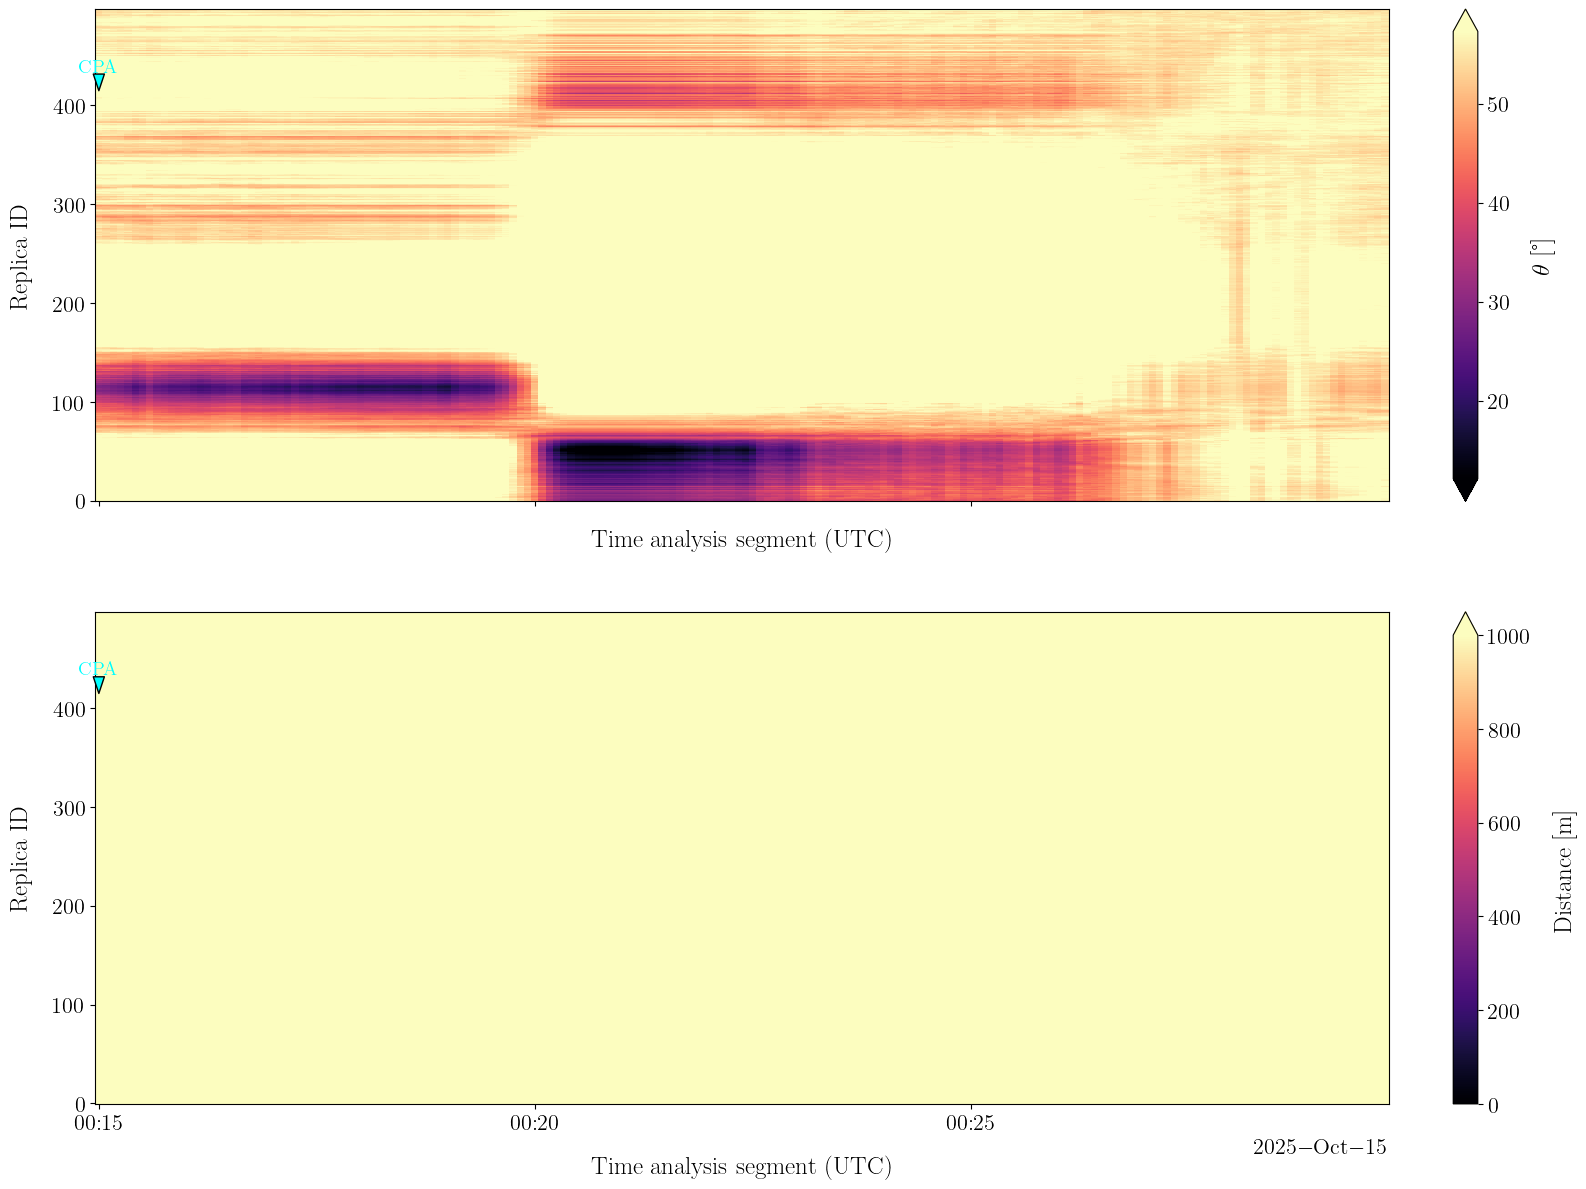

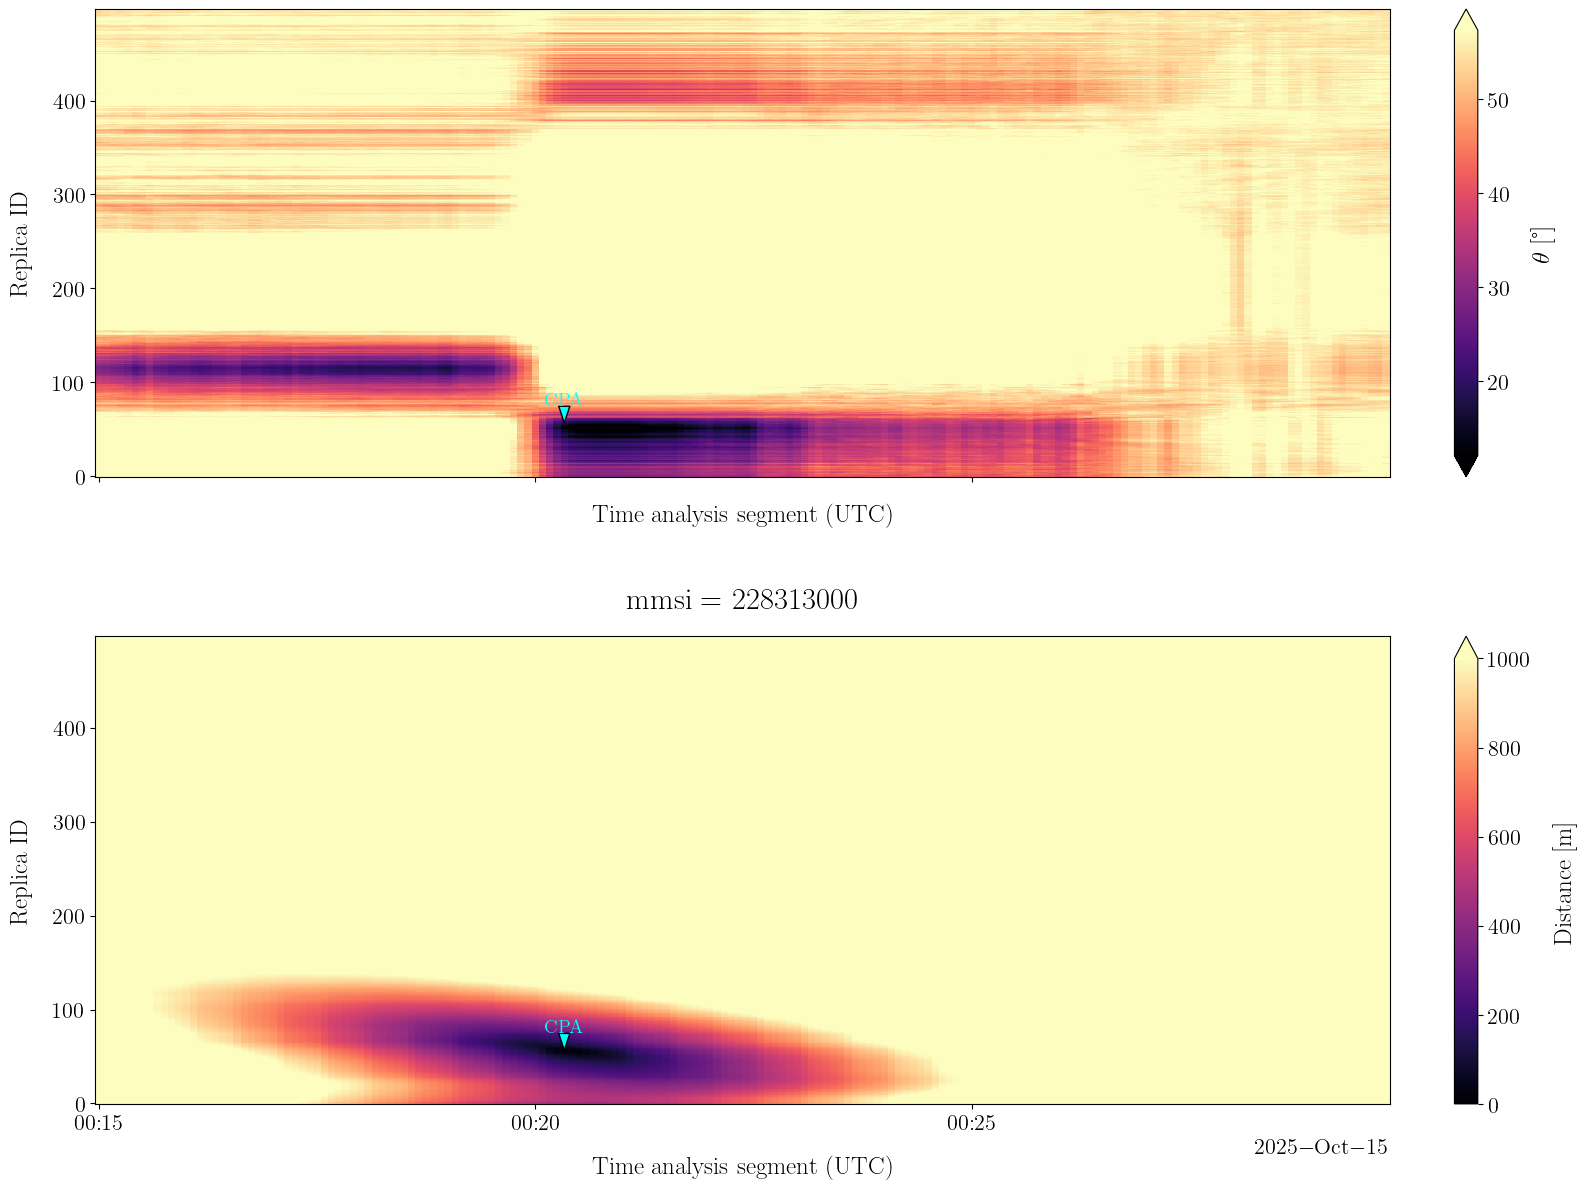

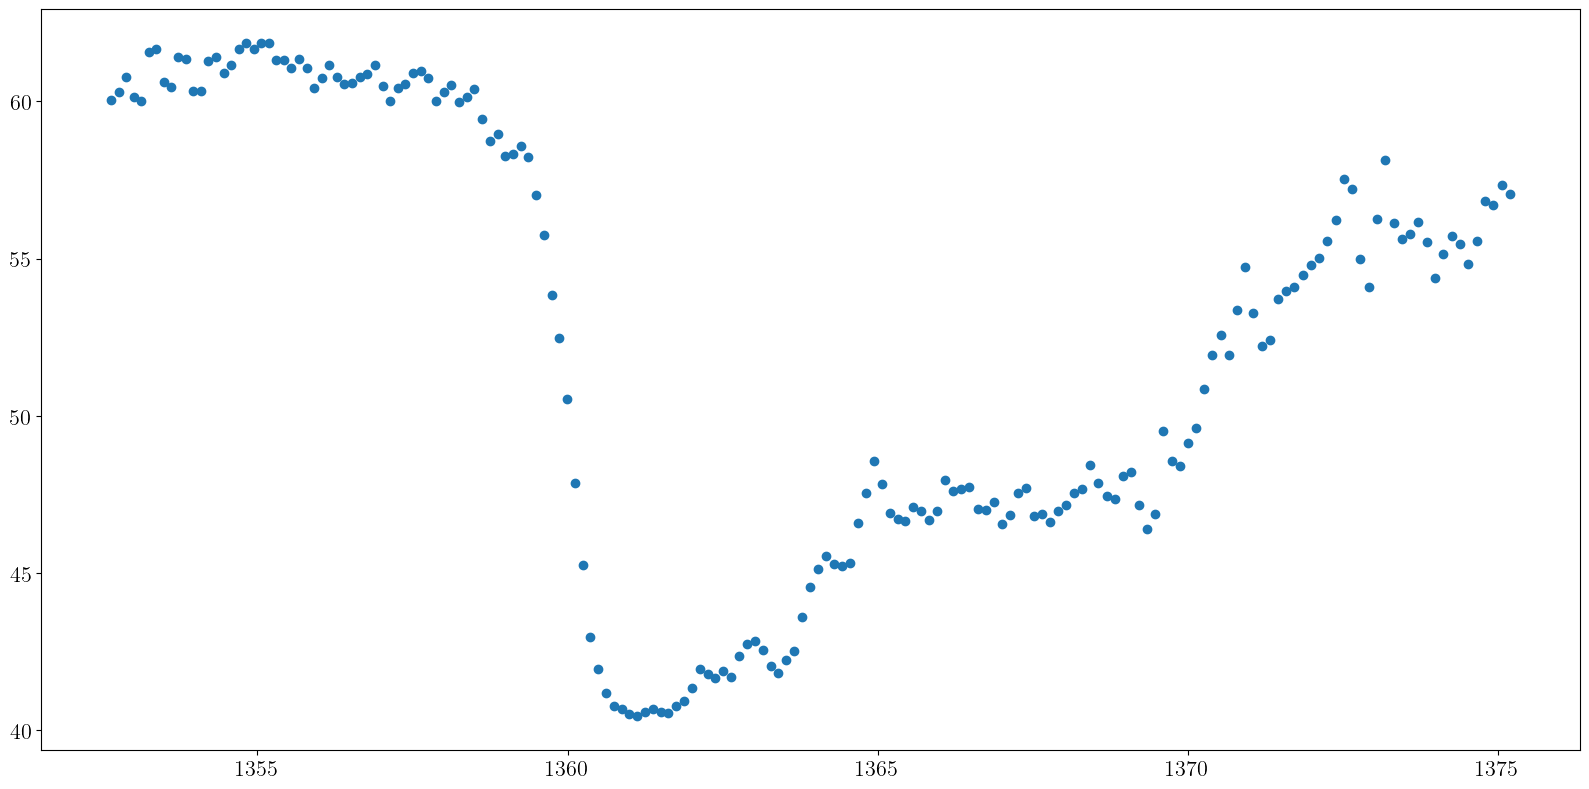

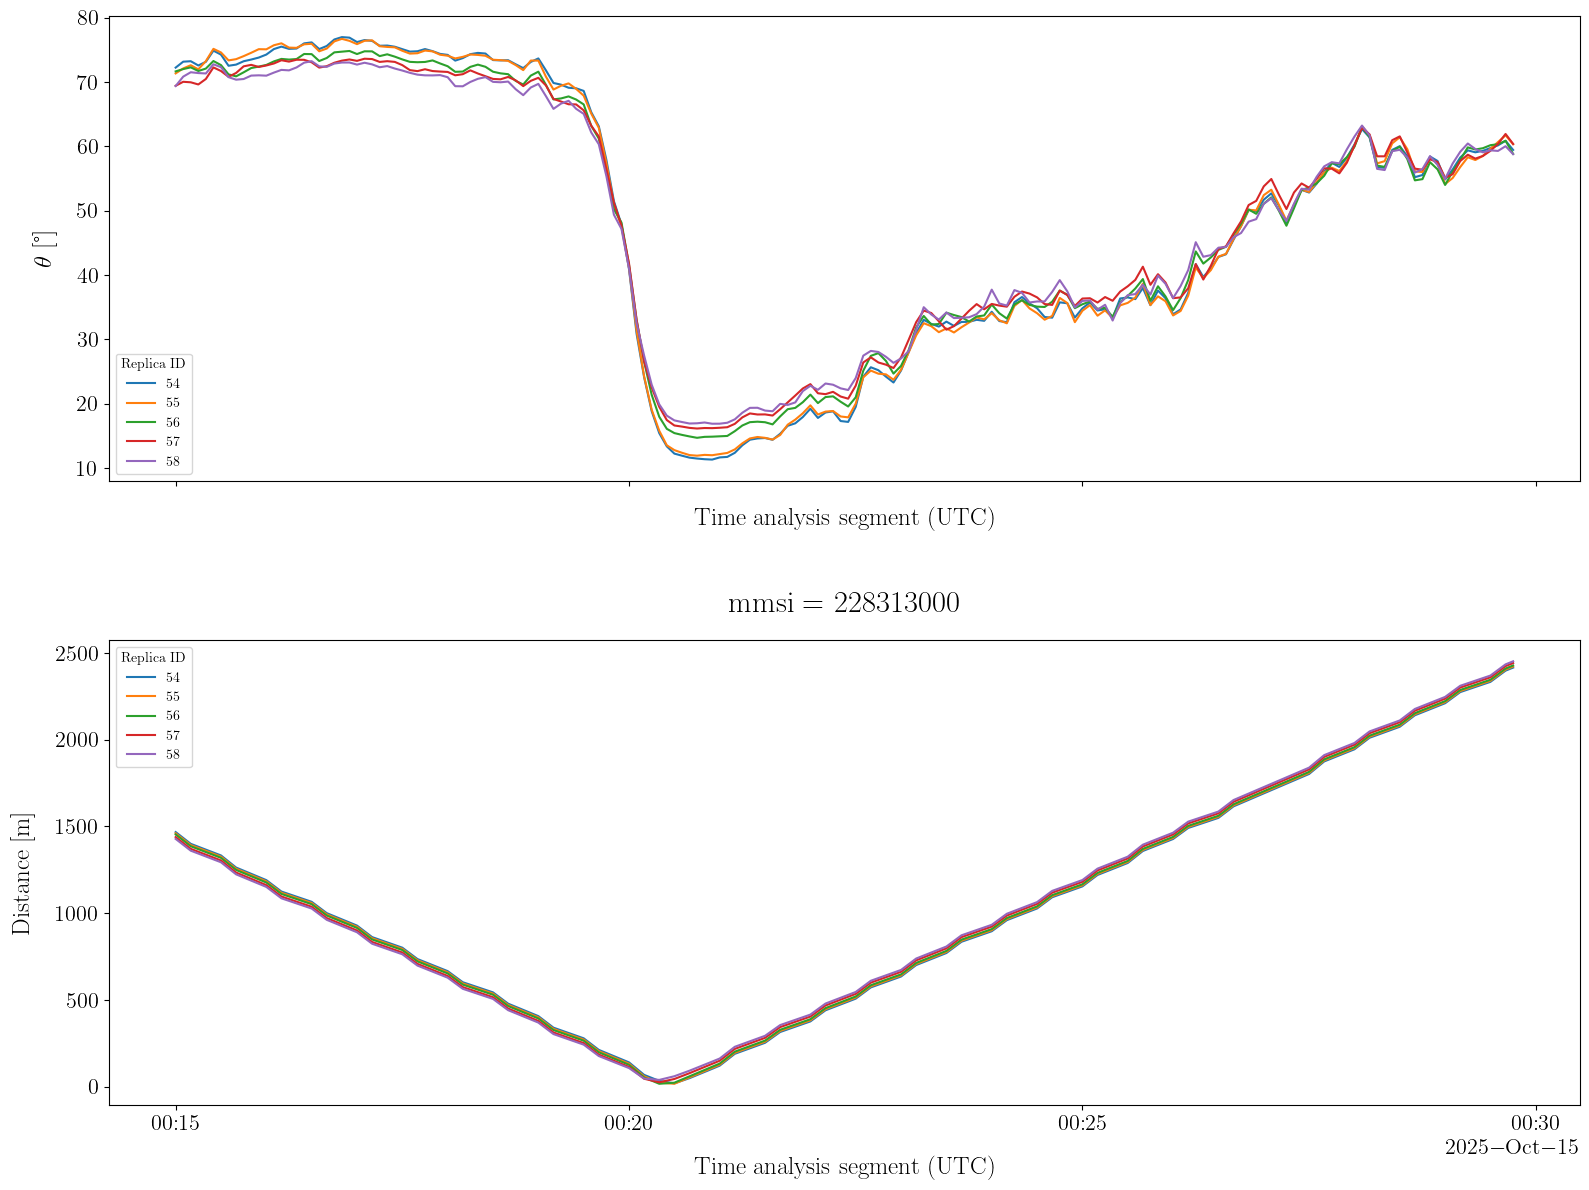

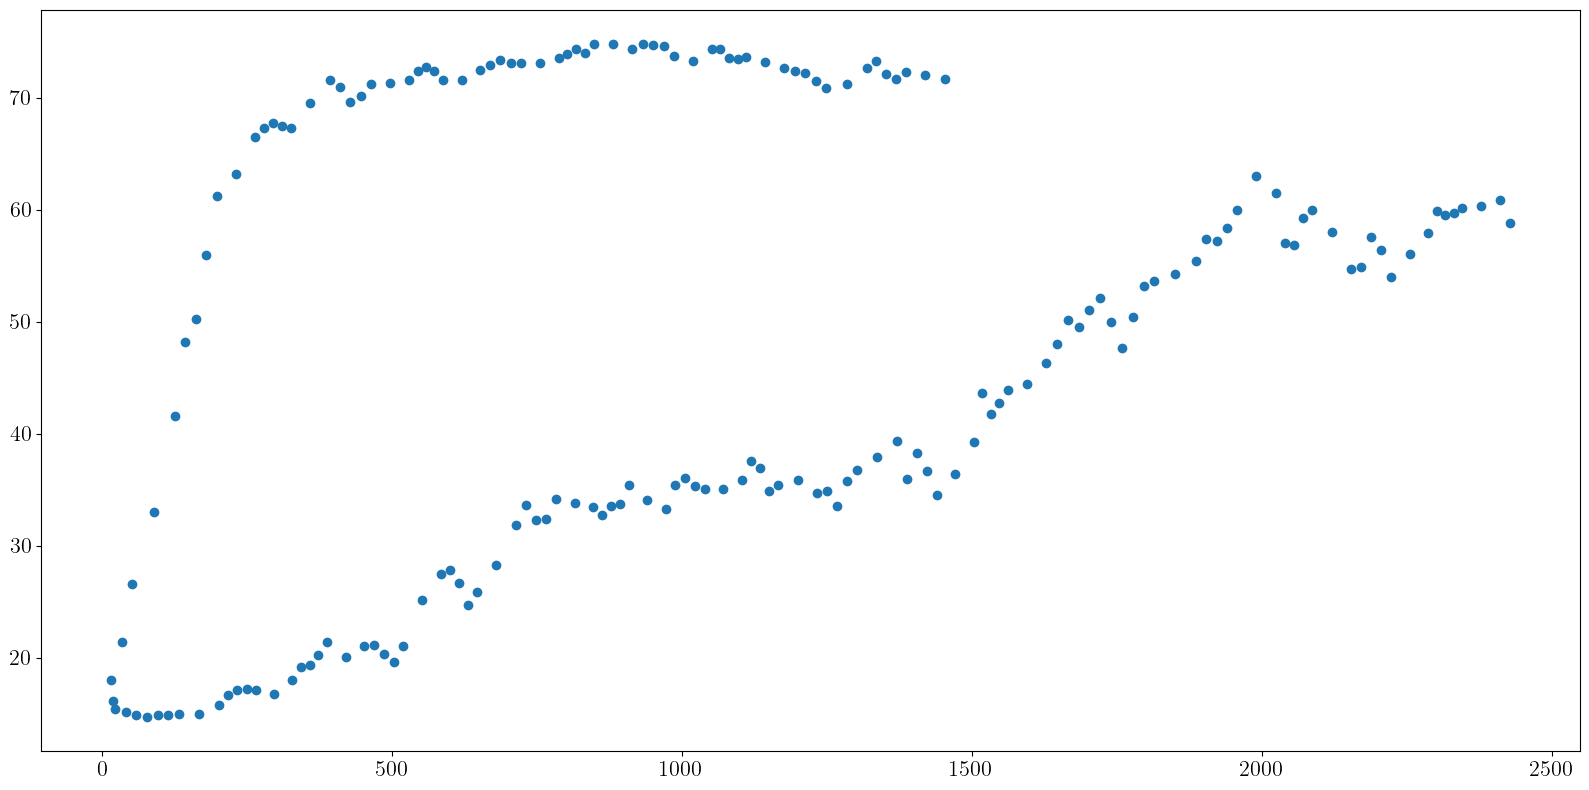

In [14]:
t_start = datetime(year=2025, month=10, day=15, hour=00, minute=15, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=00, minute=30, second=00)

root_fig = os.path.join(
    rtf_mfp_img_folder,
    f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
)
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

spectro_kwargs = dict(save=True)
theta_dist_kwargs = dict(fmin=300, fmax=900)
process_event_kwargs = dict(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    tau_ir=tau_ir_hat,
    rtf_estimator=rtf_estimator,
    bandfilter=None,
    plot_feature=False,
    process_pulse_one_by_one=True,
    estimate_ir_duration=False,
    analysis_segment_duration=10,
    analysis_segment_alpha_overlap=0.5,
    compute_rtf_event=False,  # Set to False if already computed and saved, to save time
    verbose=False,
)

process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

# Étude de séquences particulières 

## Passage de deux navires identifiés sur les données AIS 
Séquence du 15/10/2026 de 01h30 à 2h00

Gamme de fréquence testée par défaut : 

$$f_{\text{min}} = 80~\text{Hz}, f_{\text{max}} = 400~\text{Hz}$$

L'objectif est de se concentrer sur la partie basse du spectre navire la où, visuellement, l'estimation des RTFs semble la meilleur (présente des patterns marqués).  


Processing batch for event from 2025-10-15 01:30:00 to 2025-10-15 02:00:00 ...
	Filtering AIS data ...


	Plotting ships trajectories ...
	Plotting spectrograms ...


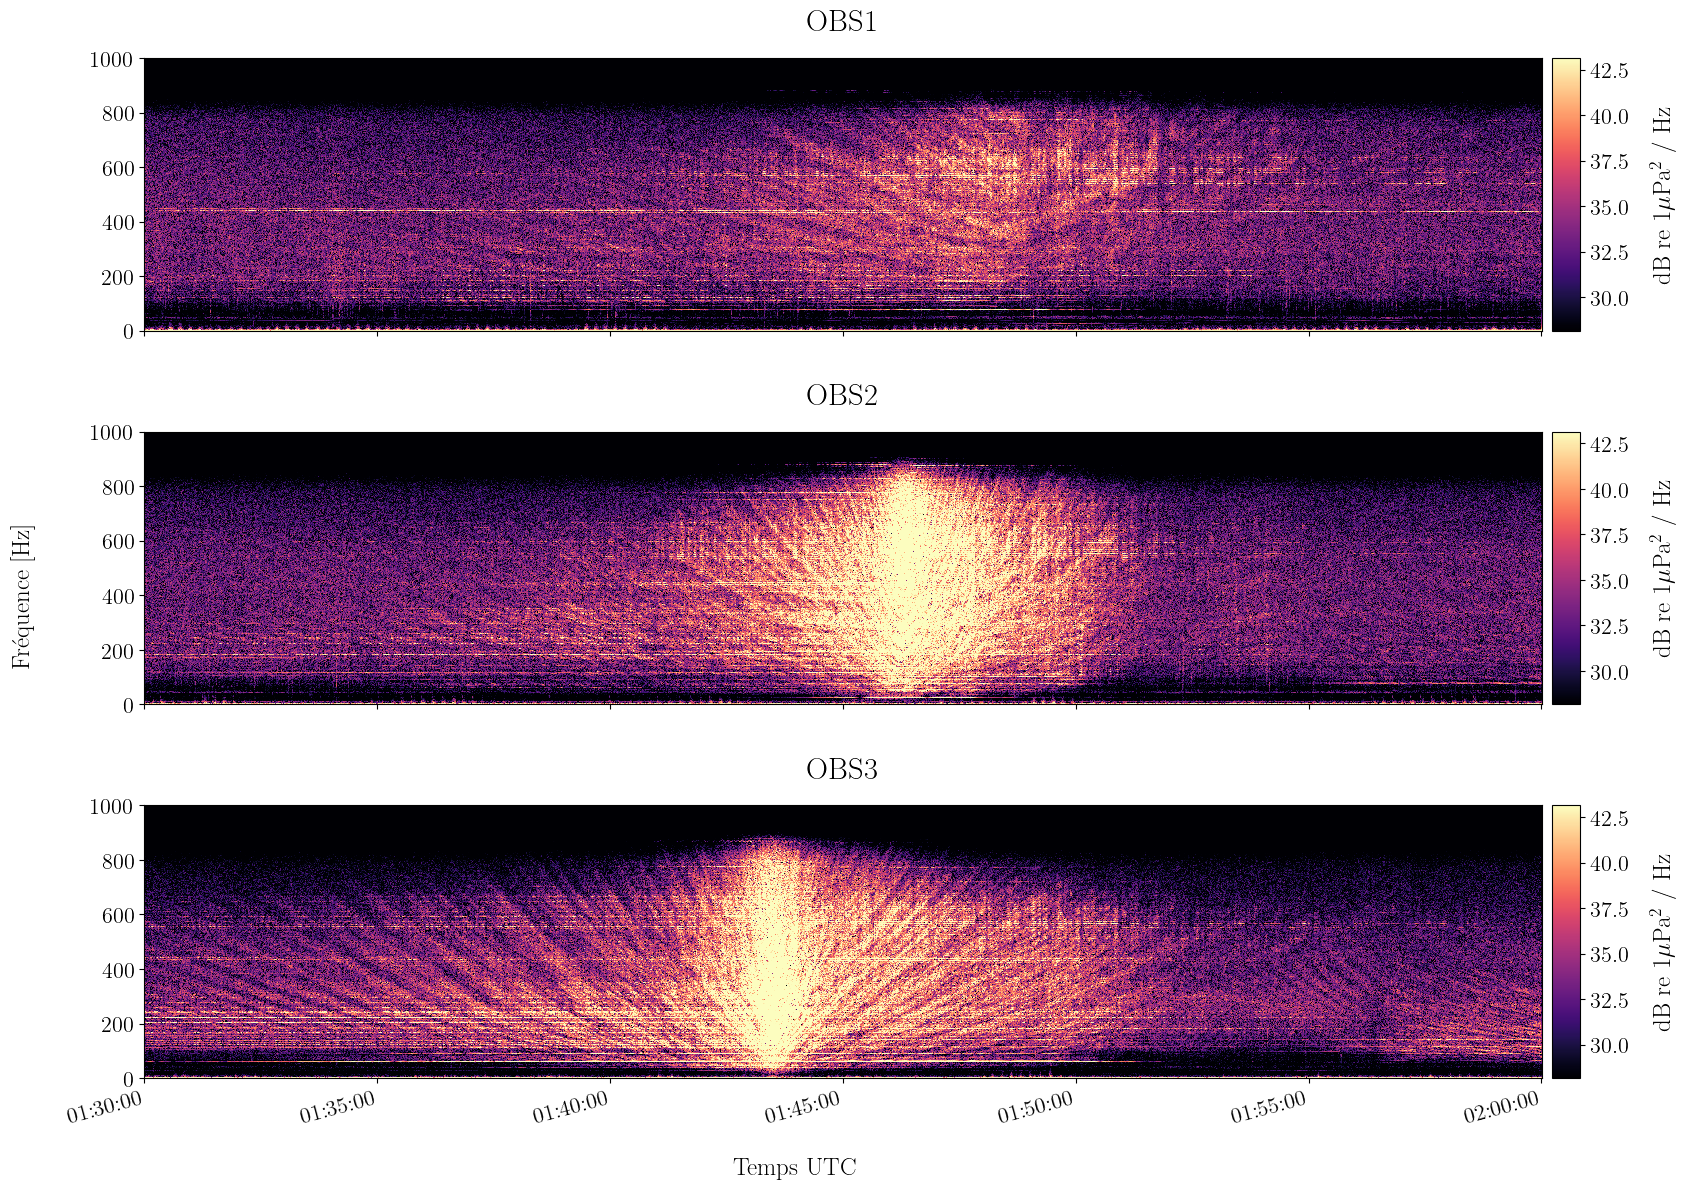

	Processing passive event (derive RTF)...
	Matching (computing hermitian angle theta) ...
		Processing library sequence 144 ...
	Computing distance from ships to library replicas positions ...
	Plotting theta vs distance from ships to library replicas positions ...
	Plotting theta vs distance from ships to library replicas positions ...


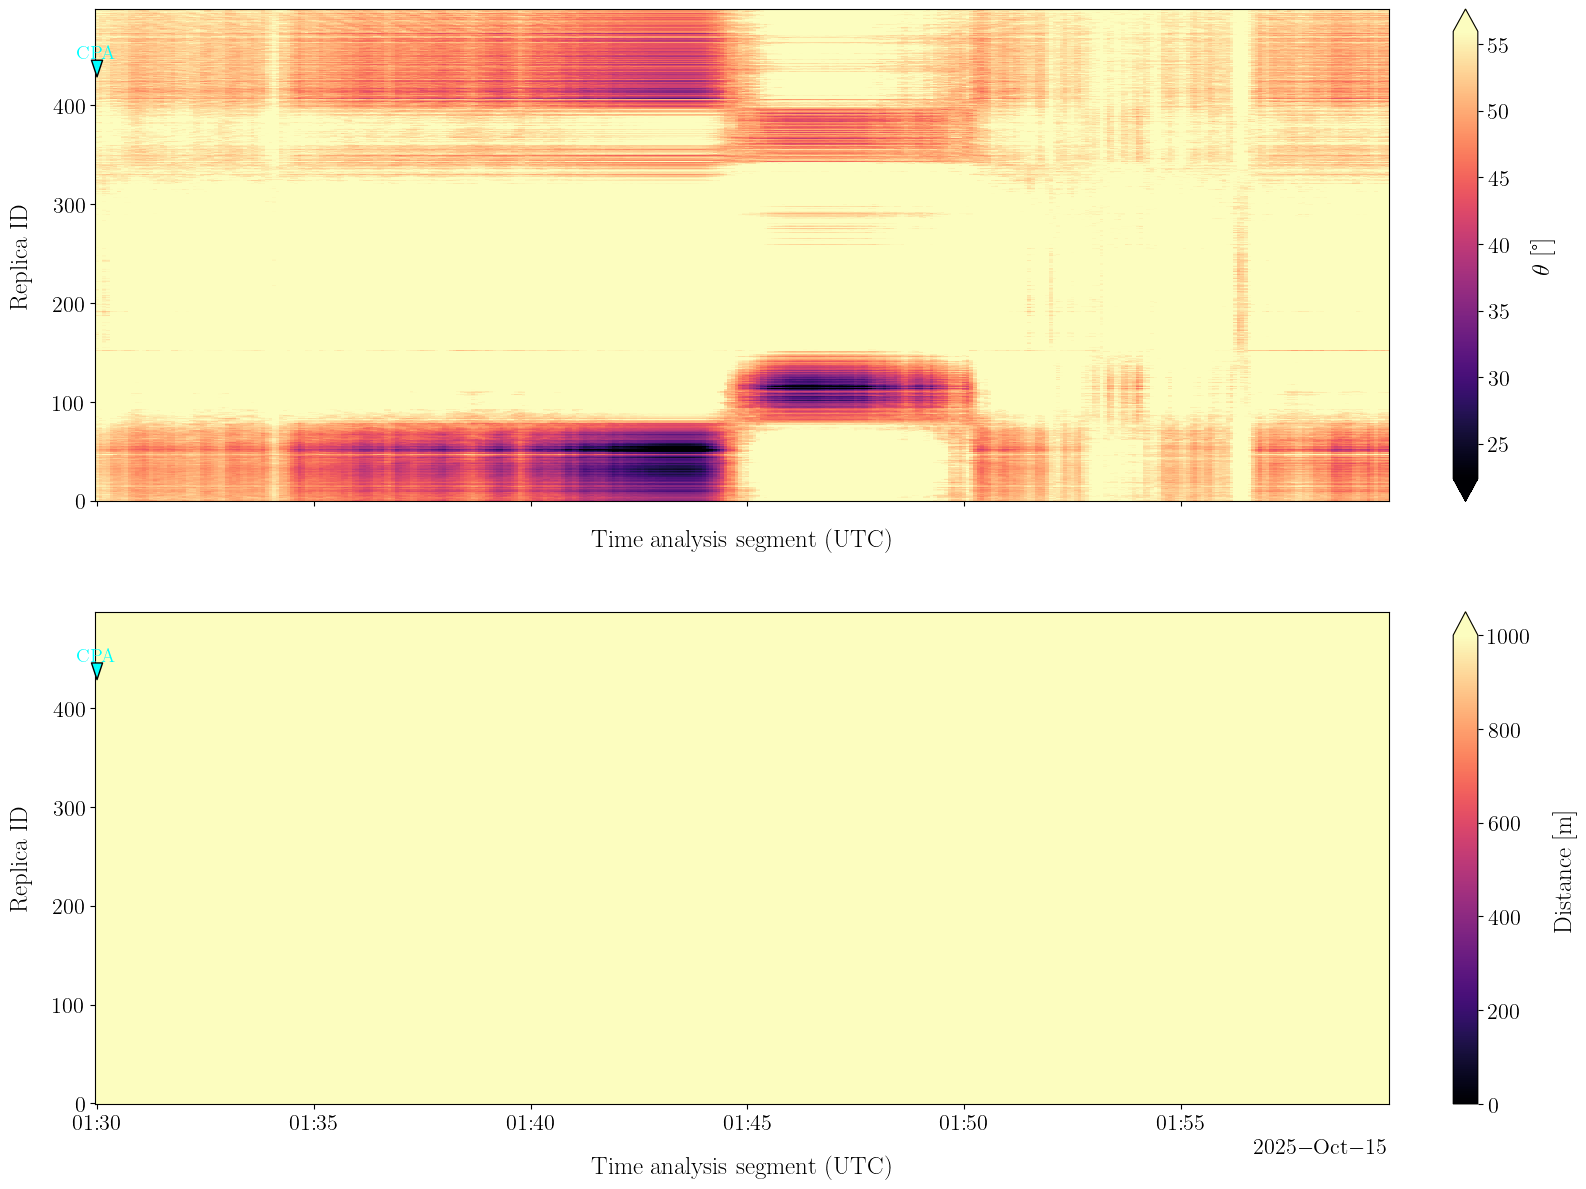

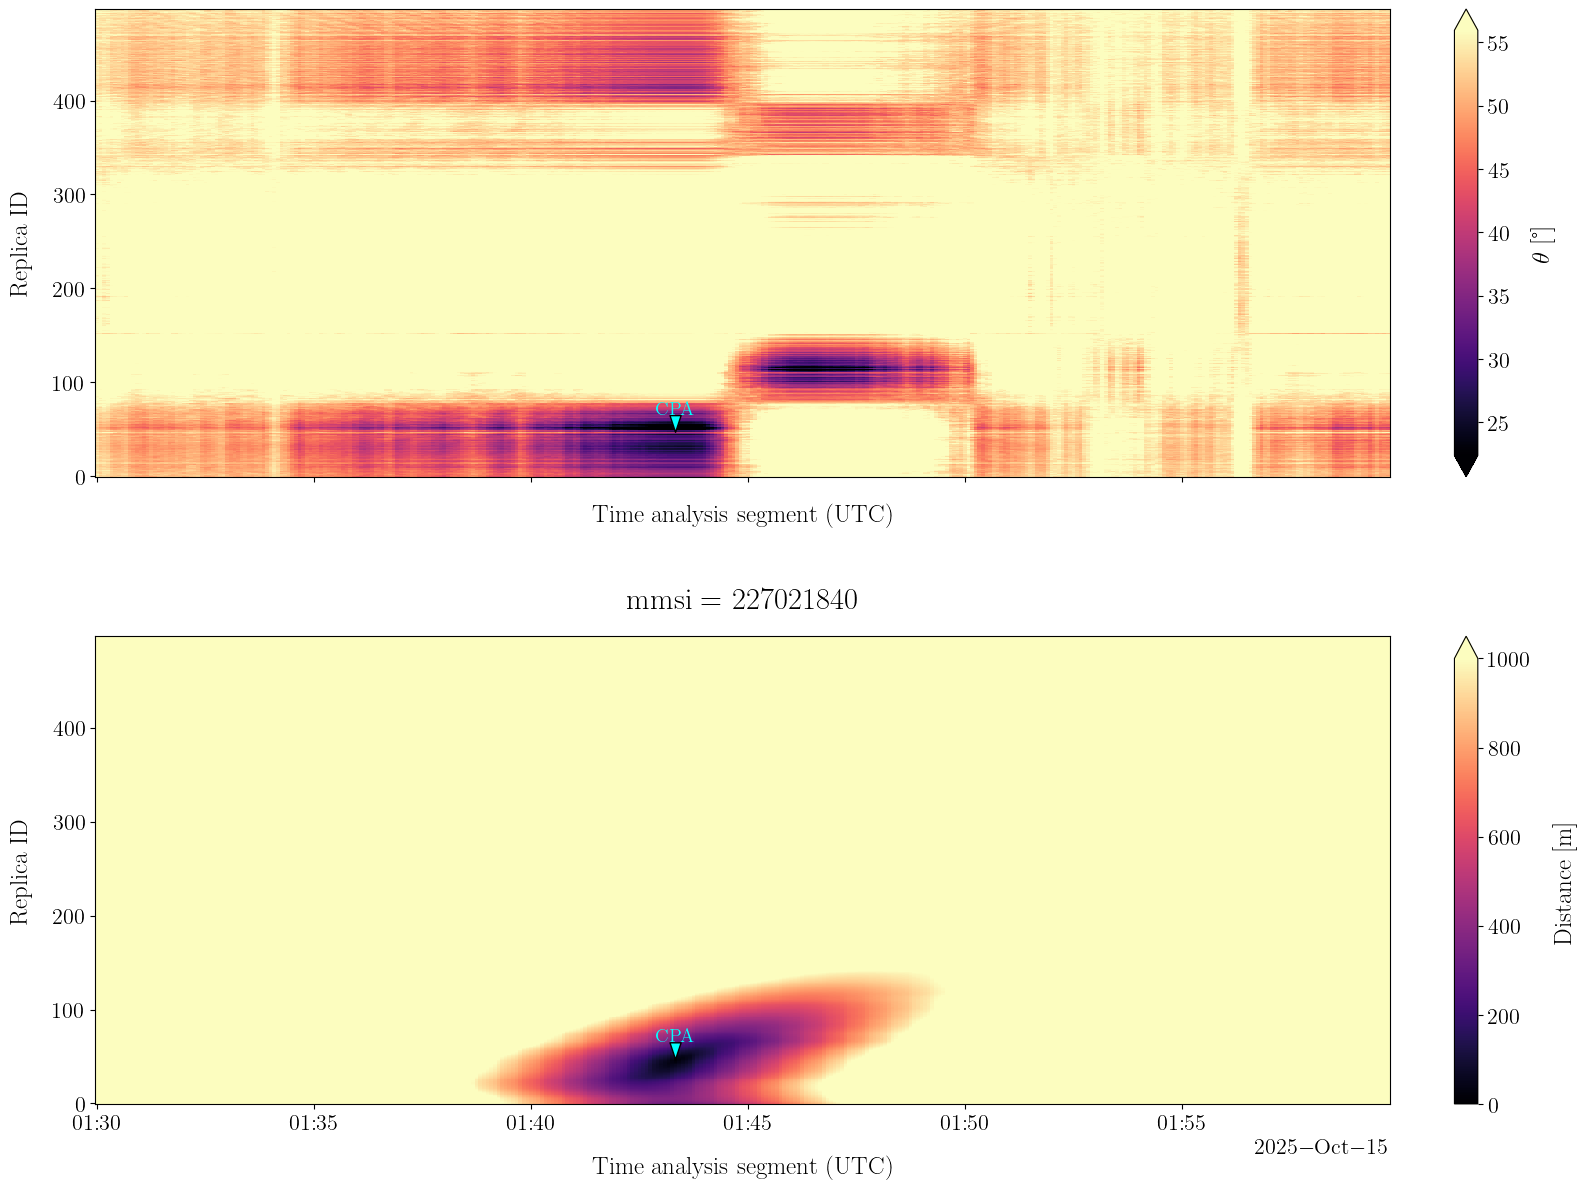

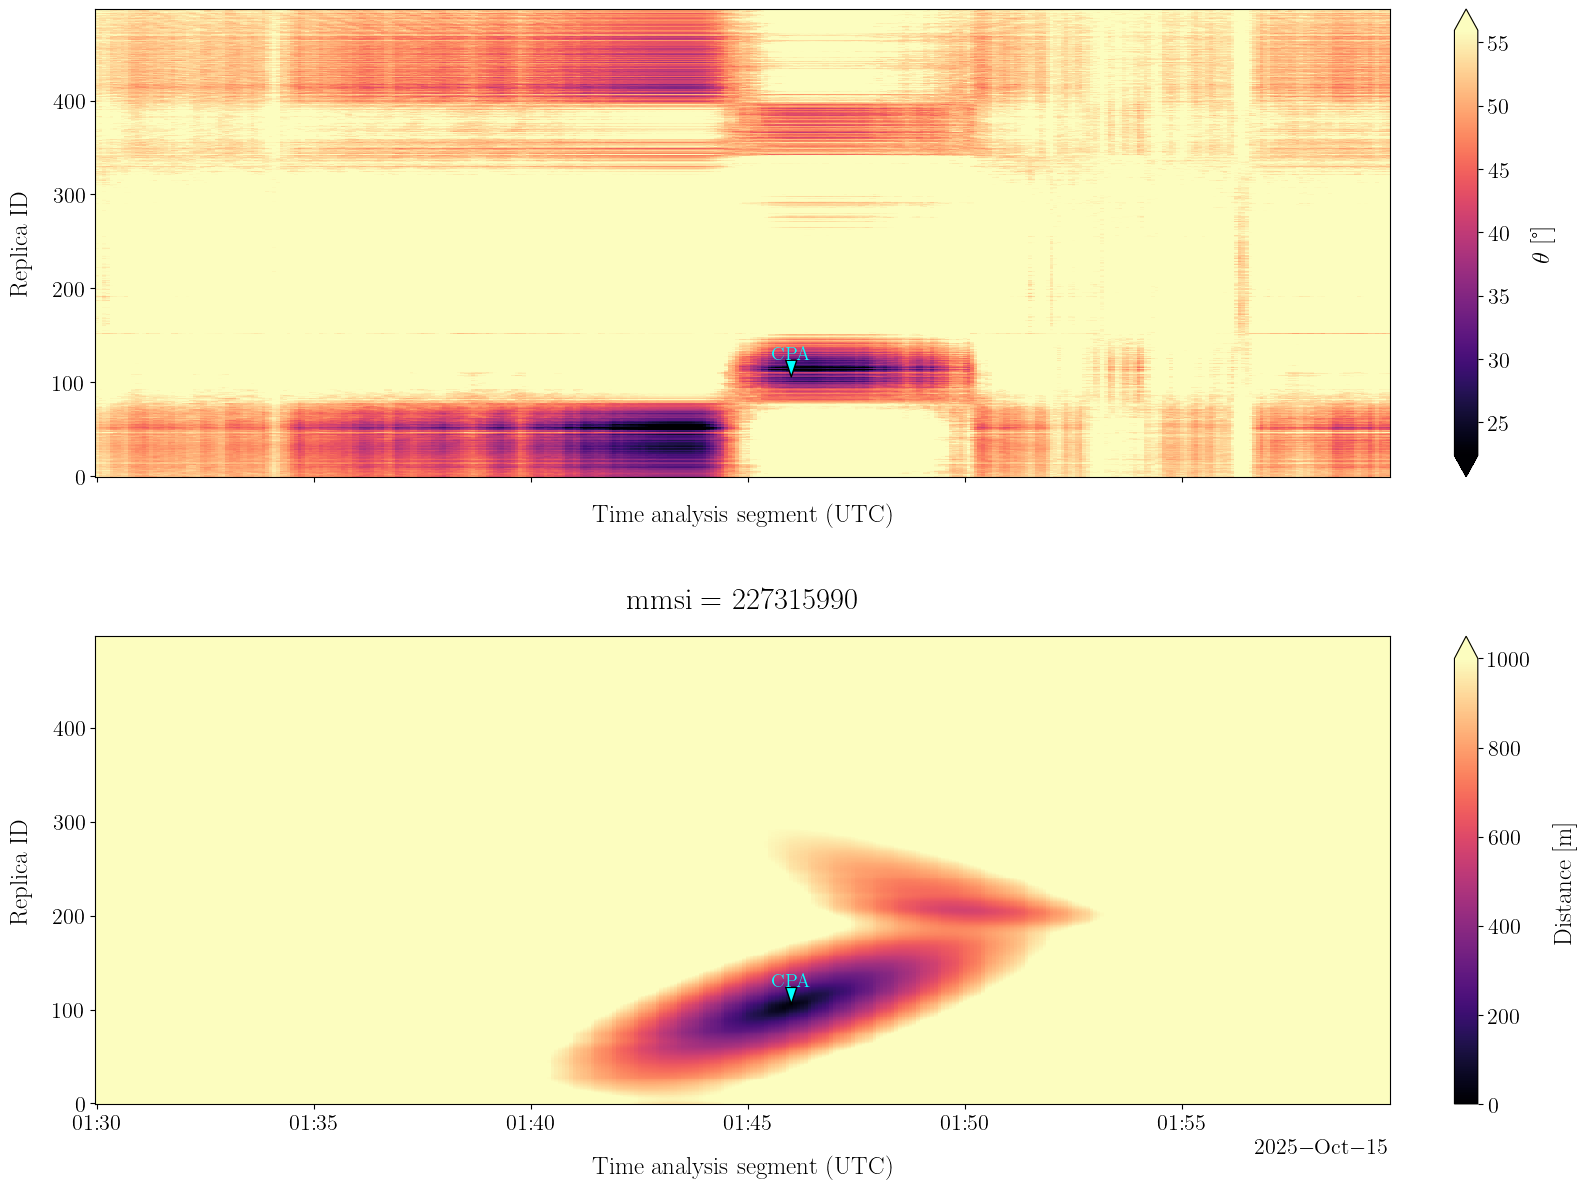

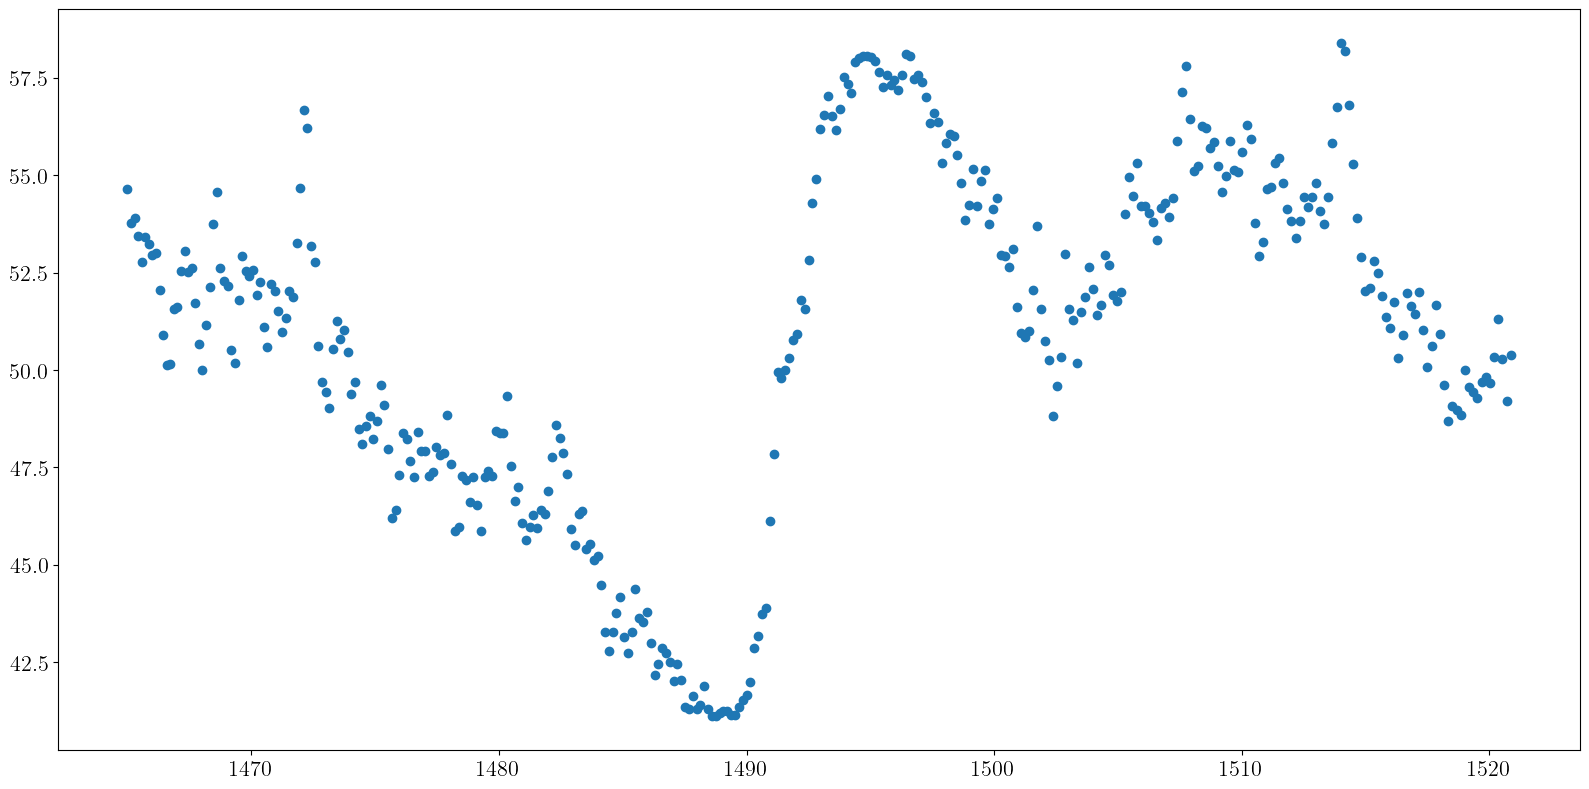

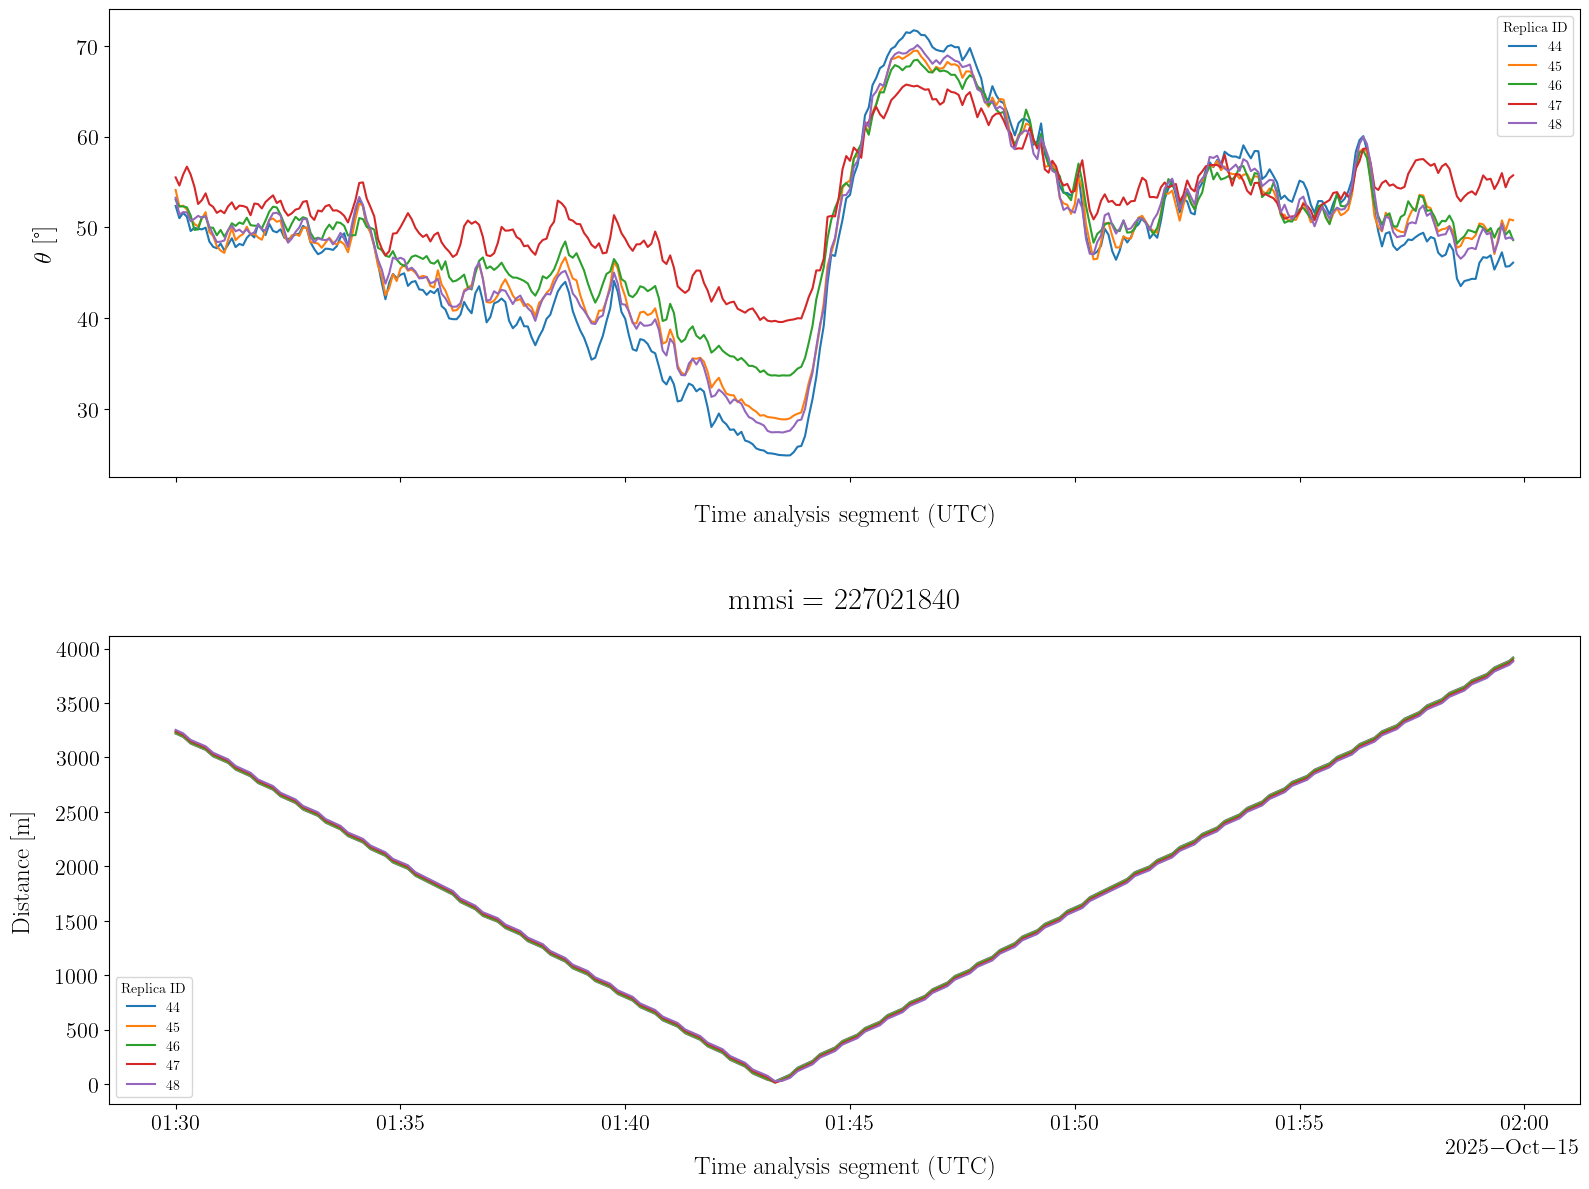

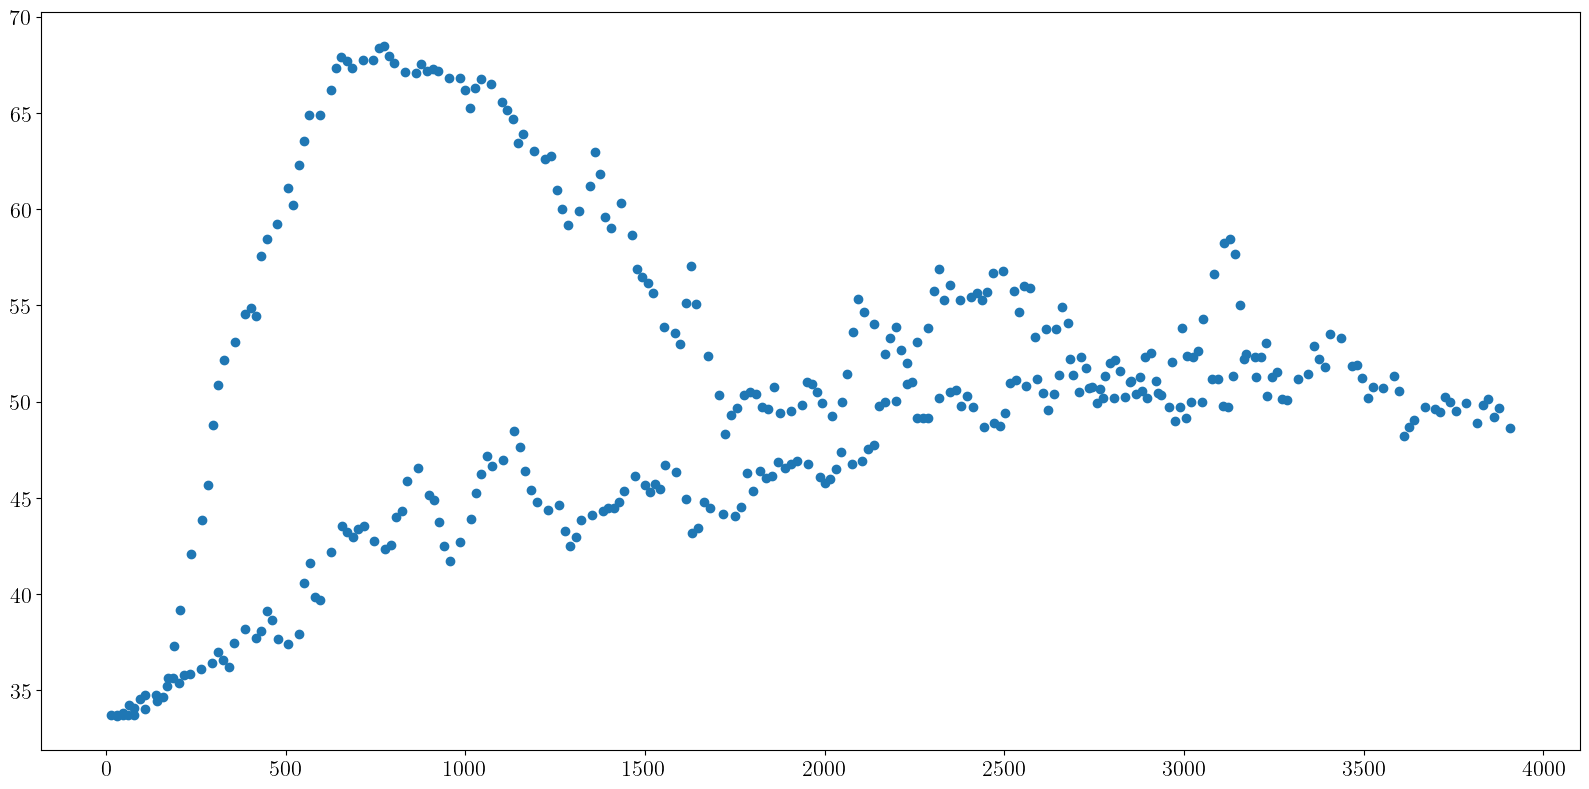

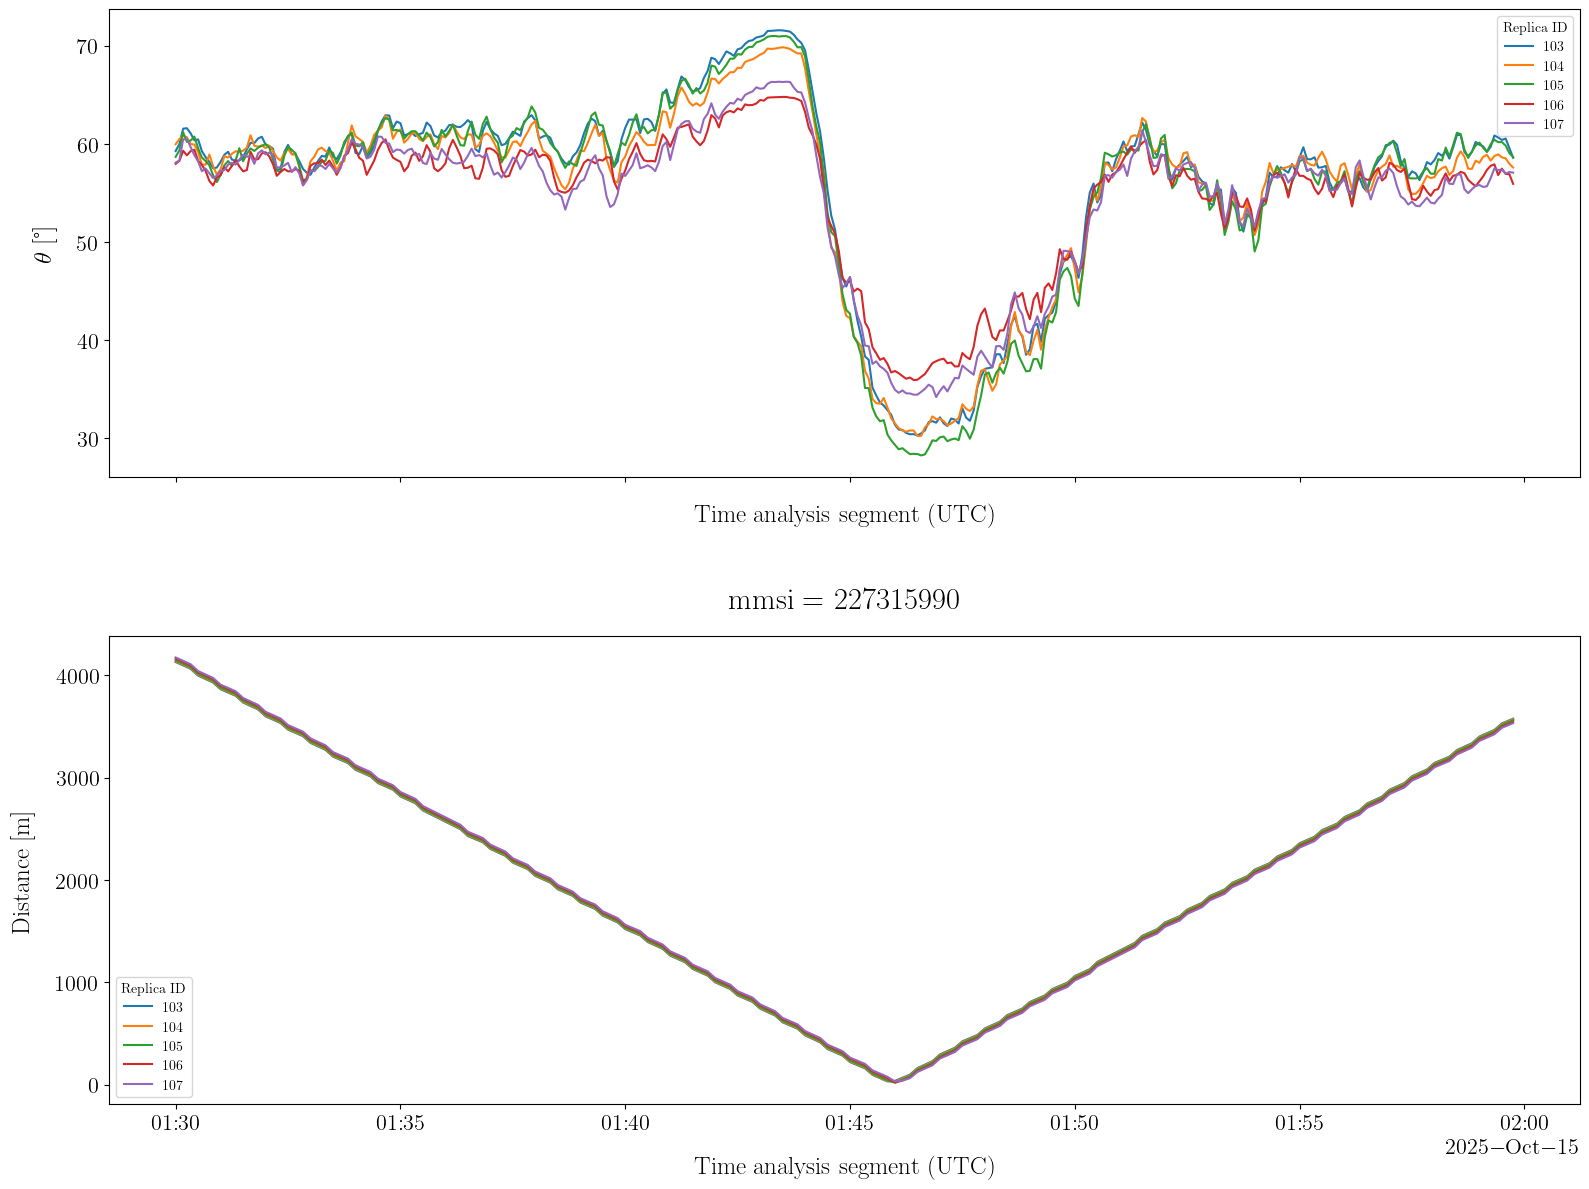

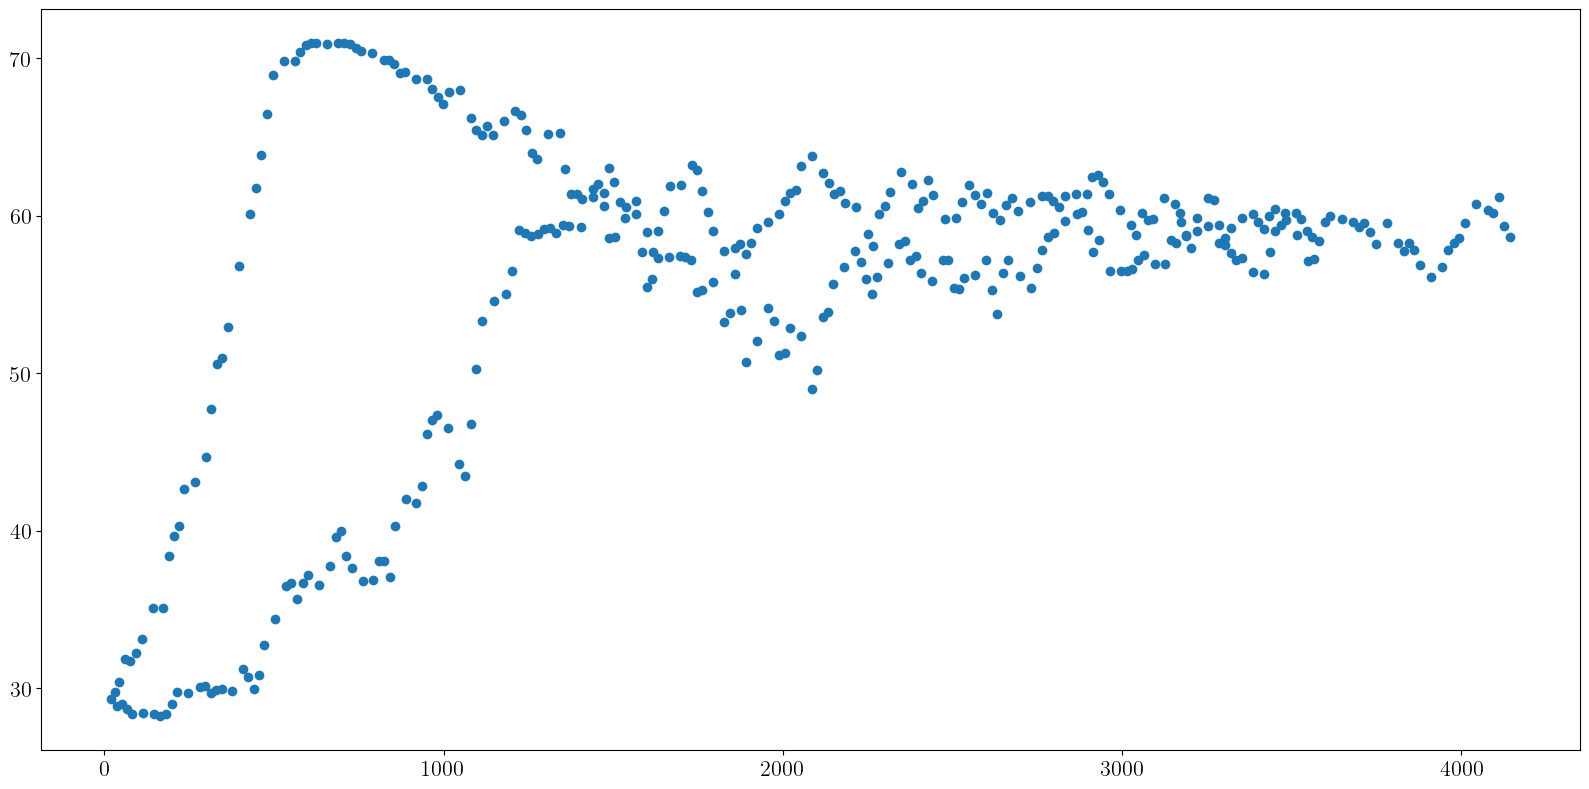

In [14]:
t_start = datetime(year=2025, month=10, day=15, hour=1, minute=30, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=2, minute=00, second=00)

root_fig = os.path.join(
    rtf_mfp_img_folder,
    f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
)
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

spectro_kwargs = dict(save=False)
theta_dist_kwargs = dict(fmin=80, fmax=400)
process_event_kwargs = dict(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    tau_ir=tau_ir_hat,
    rtf_estimator=rtf_estimator,
    bandfilter=None,
    plot_feature=False,
    process_pulse_one_by_one=True,
    estimate_ir_duration=False,
    analysis_segment_duration=10,
    analysis_segment_alpha_overlap=0.5,
    compute_rtf_event=False,       # Set to False if already computed and saved, to save time
    verbose=False,
)

process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

La distance $\theta$ présente des minimums qui coïncident avec les figures d'interférence typique du passage au CPA ainsi qu'avec les CPAs visibles sur les données AIS.

Comme on peut le remarquer, la distance $\theta$ associée à certaines répliques reste très faible quelle que soit la position des navires dans la zone. En particulier, les répliques ID = 47, ID = 48, présente un angle hermitien important même au passage d'un navire. Ce phénomène traduit la mauvaise qualité de ces répliques dans cette gamme de fréquence. En effet, on peut le vérifier en regardant le détail des répliques estimées dans le dossier *sequences*. La matrice de covariance du bruit associée aux répliques 47, 48, traduit un SNR plus faible que pour les répliques précèdentes et suivantes. De plus, le module des RTFs estimés pour ces répliques est clairement bruité à basse fréquence (en dessous de 300 Hz)! 



Pour se convaincre de cette effet on peut reprendre le calcul avec une gamme de fréquence plus restreinte, de 300 à 400 Hz. 

In [ ]:
theta_dist_kwargs = dict(fmin=300, fmax=400)
process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

Le minimum observé est largement estompé, le minimum de $\theta$ au passage des navires est plus faible. 

In [ ]:
theta_dist_kwargs = dict(fmin=300, fmax=900)
process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

In [ ]:
spectro_kwargs = dict(save=False)
theta_dist_kwargs = dict(fmin=300, fmax=900, use_weighted_mean=True)
process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

## Passage du Jules en passif et nombreux bateaux non repérés sur les données AIS 
Séquence du 14/10/2026 de 12h30 à 13h30

Gamme de fréquence testée par défaut : 

$$f_{\text{min}} = 80~\text{Hz}, f_{\text{max}} = 400~\text{Hz}$$

L'objectif est de se concentrer sur la partie basse du spectre navire la où, visuellement, l'estimation des RTFs semble la meilleur (présente des patterns marqués).  

In [ ]:
#
t_start = datetime(year=2025, month=10, day=14, hour=12, minute=30, second=00)
t_end = datetime(year=2025, month=10, day=14, hour=13, minute=30, second=00)

root_fig = os.path.join(
    rtf_mfp_img_folder,
    f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
)
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

spectro_kwargs = dict(save=False)
theta_dist_kwargs = dict(fmin=80, fmax=400)
process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

La distance $\theta$ présente des minimums qui coïncident avec les figures d'interférence typique du passage au CPA. 

Comme on peut le remarquer, la 

In [ ]:
theta_dist_kwargs = dict(fmin=200, fmax=900)
process_batch(
    ds_wav,
    ds_gps,
    ds_ais,
    df_library,
    t_start,
    t_end,
    root_results_fig=root_fig,
    root_results_data=root_rtf_data_res,
    compute_rtf_event=False,
    compute_animation=False,
    theta_dist_kwargs=theta_dist_kwargs,
    spectro_kwargs=spectro_kwargs,
    process_event_kwargs=process_event_kwargs,
)

**Remarque** : 

Ces résultats illustrent un phénomène important. La faible distance observée dépend à la fois de la proximité entre la source et la réplique considérée (c'est tout l'objectif de la méthode), mais aussi de la qualité de la réplique considérée. Ainsi, des répliques générées avec un faible SNR apportent moins d'information et peuvent conduire, dans des cas où la réplique est très bruitée, à un angle hermitien indépendant de la distance de la source à la réplique. 

Cet aspect s'illustre au travers des minimums de la distance $\theta$. En effet, alors qu'il est peu probable que les navires soient réellement passés au-dessus de la fibre au même endroit, chacun des CPAs est vu autour de la même réplique. Les minimums de $\theta$ correspondent en réalité au passage au CPA de chacun des capteurs de la source tractée ayant servi à générer la librairie de répliques. Au vu de cette première analyse, il semble essentiel de compenser cet effet pour espérer obtenir une localisation précise. 

Pour pallier ce problème, on peut notamment envisager d'utiliser une moyenne pondérée plutôt que la moyenne empirique simple des angles $\theta$ évalués sur toute la gamme de fréquence. En particulier, une pondération basée sur la DSP du signal reçu avait été envisagée pour utiliser, en priorité, l'information contenue dans les bandes de fréquences des raies navires : 

$$
\begin{equation}
	\hat{\theta} = \frac{1}{\sum_{k=1}^{K} w_k} \sum_{k=1}^{K} w_k \theta_k
\end{equation}
$$

avec

$$
\begin{equation}
	w_k = \frac{\hat{S_{x_lx_l}}^{(dB)}[k] + \lvert \min_{k \in K}\left ({\hat{S_{x_lx_l}}^{(dB)}[k]}  \right ) \rvert}{\max_{k \in K} \left ( {\hat{S_{x_lx_l}}^{(dB)}[k] + \lvert \min_{k \in K}{\hat{S_{x_lx_l}}^{(dB)}[k]} \rvert} \right ) }
\end{equation}
$$

On pourrait éventuellement étendre cette approche en prenant également en compte la DSP du signal ayant servi à générer les répliques. L'idée serait alors de pondérer la moyenne des $\theta$ en utilisant des poids pour les parties énergétiques du spectre communes à la source *library* et à la source *event*. Le plus simplement : 

$$
\begin{equation}
	w_k = \frac{1}{2} (w_k^{(l)} + w_k^{(e)})
\end{equation}
$$

avec 


$$
\begin{equation}
	w_k^{(l)} = \frac{\hat{S_{x_lx_l}}^{(dB)}[k] + \lvert \min_{k \in K}\left ({\hat{S_{x_lx_l}}^{(dB)}[k]}  \right ) \rvert}{\max_{k \in K} \left ( {\hat{S_{x_lx_l}}^{(dB)}[k] + \lvert \min_{k \in K}{\hat{S_{x_lx_l}}^{(dB)}[k]} \rvert} \right ) }
\end{equation}
$$

et
$$
\begin{equation}
	w_k^{(e)} = \frac{\hat{S_{x_e x_e}}^{(dB)}[k] + \lvert \min_{k \in K}\left ({\hat{S_{x_e x_e}}^{(dB)}[k]}  \right ) \rvert}{\max_{k \in K} \left ( {\hat{S_{x_e x_e}}^{(dB)}[k] + \lvert \min_{k \in K}{\hat{S_{x_e x_e}}^{(dB)}[k]} \rvert} \right ) }
\end{equation}
$$

<!-- $$
\begin{equation}
	w_k = \frac{\hat{S_{x_lx_l}}^{(dB)}[k] + \alpha_l[k] + \hat{S_{x_ex_e}}^{(dB)}[k] + \alpha_e[k] }{\max_{k \in K} \left ( {\hat{S_{x_l x_l}}^{(dB)}[k] + \alpha_l[k]  +  {\hat{S_{x_e x_e}}^{(dB)}[k] + \alpha_e[k] } } \right ) }
\end{equation}
$$

avec 
$$ \alpha_l[k] =  \lvert \min_{k \in K}\left ({\hat{S_{x_lx_l}}^{(dB)}[k]}  \right ) \rvert $$

et 

$$ \alpha_e[k] =  \lvert \min_{k \in K}\left ({\hat{S_{x_e x_e}}^{(dB)}[k]}  \right ) \rvert $$ -->


# Batch processing

In [ ]:
# start_dates = [
#     datetime.strptime(ds_wav.attrs[f"start_datetime_obs{i}"], ds_wav.datetime_format)
#     for i in range(1, 4)
# ]
# end_dates = [
#     datetime.strptime(ds_wav.attrs[f"end_datetime_obs{i}"], ds_wav.datetime_format)
#     for i in range(1, 4)
# ]
# min_t = np.max(start_dates)
# max_t = np.min(end_dates)

# min_t = datetime(year=2025, month=10, day=14, hour=00, minute=00, second=00)
# # batch_duration = timedelta(minutes=10)
# # batch_overlap = timedelta(minutes=1)
# batch_duration = timedelta(minutes=60)
# batch_overlap = timedelta(minutes=10)
# t_start = min_t

# batch_duration_str = f"{int(batch_duration.total_seconds()//60)}min"

# i_pb = 0
# prev_progress = 0
# indexf = int(np.ceil((max_t - min_t) / (batch_duration - batch_overlap)))
# # indexf = 1


# # while t_start < max_t:
# while i_pb < indexf:

#     i_pb += 1
#     prev_progress = progression_bar(
#         index=i_pb,
#         index0=0,
#         indexf=indexf,
#         prev_progress=prev_progress,
#     )

#     t_end = t_start + batch_duration
#     t_end = min(t_end, max_t)  # Ensure we don't go beyond the max time

#     root_fig = os.path.join(
#         rtf_mfp_img_folder,
#         batch_duration_str,
#         f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}",
#     )
#     if not os.path.exists(root_fig):
#         os.makedirs(root_fig)


#     process_batch(ds_wav, ds_gps, ds_ais, df_library, t_start, t_end, root_fig)
#     t_start = t_end - batch_overlap  # Start the next batch with the specified overlap

#     # print(t_start)